# Laboratorio 7 - Spark MLlib
CC3066 - Data Science  

## Análisis exploratorio avanzado y segmentación

### Integrantes

- María José Girón Isidro
- Leonardo Dufrey Mejía Mejía
- Mia Alejandra Fuentes Mérida

---

## Objetivo

En este notebook se realiza la preparación, análisis exploratorio y
segmentación de los datos de Personas de la Encuesta Nacional de Empleo
e Ingresos Continua (ENEIC).

Para el desarrollo se utilizan los cuatro trimestres correspondientes
al año 2025. El primer trimestre de 2026 se mantiene separado para la
evaluación final.

In [25]:
import os
import math
import pandas as pd
import numpy as np
import openpyxl
import gc

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

import matplotlib.pyplot as plt

In [3]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Laboratorio7-ENEIC")
    .getOrCreate()
)

print("Versión de Spark:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 22:08:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Versión de Spark: 3.5.1


In [4]:
print("Estoy trabajando en:")
print(os.getcwd())
print("Archivos disponibles:")
print(os.listdir("."))
print(os.listdir("./data"))

Estoy trabajando en:
/opt/app/CC3084-Laboratorio7
Archivos disponibles:
['data', 'Laboratorio7.ipynb', '.ipynb_checkpoints']
['Personas_ENEIC_T1_2025.xlsx', 'diccionarios', '.ipynb_checkpoints', 'Personas-ENEIC-T2-2025.xlsx', 'Base-de-datos-Personas-ENEIC-IV-2025.xlsx', 'Base-de-datos-Personas-ENEIC-I-2026.xlsx', 'Base-de-datos-Personas-ENEIC-III-2025.xlsx']


In [5]:
DATA_DIR = "./data"

ARCHIVOS = {
    "2025T1": {
        "ruta": f"{DATA_DIR}/Personas_ENEIC_T1_2025.xlsx",
        "anio": 2025,
        "trimestre": 1
    },
    "2025T2": {
        "ruta": f"{DATA_DIR}/Personas-ENEIC-T2-2025.xlsx",
        "anio": 2025,
        "trimestre": 2
    },
    "2025T3": {
        "ruta": f"{DATA_DIR}/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
        "anio": 2025,
        "trimestre": 3
    },
    "2025T4": {
        "ruta": f"{DATA_DIR}/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
        "anio": 2025,
        "trimestre": 4
    },
    "2026T1": {
        "ruta": f"{DATA_DIR}/Base-de-datos-Personas-ENEIC-I-2026.xlsx",
        "anio": 2026,
        "trimestre": 1
    }
}

for periodo, info in ARCHIVOS.items():
    print(periodo, "->", os.path.exists(info["ruta"]))

2025T1 -> True
2025T2 -> True
2025T3 -> True
2025T4 -> True
2026T1 -> True


In [6]:
COLUMNAS_REQUERIDAS = [
    "P05D01",       # salario mensual
    "P02A03",       # edad
    "P05C07A",      # antigüedad años
    "P05C07B",      # antigüedad meses
    "P05H01A",      # horas semanales
    "P03A03A",      # nivel educativo
    "P05C16",       # categoría ocupacional
    "DOMINIO",      # dominio
    "OCUPADOS",     # condición de ocupado
    "NUM_HOGAR",
    "NUM_PERSONA",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

RENOMBRES = {
    "P05D01": "salario_mensual",
    "P02A03": "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16": "categoria_ocupacional",
    "DOMINIO": "dominio",
    "OCUPADOS": "ocupado"
}

In [9]:
for periodo, info in ARCHIVOS.items():

    encabezado = pd.read_excel(
        info["ruta"],
        engine="openpyxl",
        nrows=0
    )

    columnas = list(encabezado.columns)

    faltantes = [
        col for col in COLUMNAS_REQUERIDAS
        if col not in columnas
    ]

    print(f"\n{periodo}")
    print(f"Columnas totales: {len(columnas)}")
    print(f"Columnas requeridas faltantes: {faltantes}")


2025T1
Columnas totales: 270
Columnas requeridas faltantes: []

2025T2
Columnas totales: 270
Columnas requeridas faltantes: []

2025T3
Columnas totales: 270
Columnas requeridas faltantes: []

2025T4
Columnas totales: 302
Columnas requeridas faltantes: []

2026T1
Columnas totales: 270
Columnas requeridas faltantes: []


In [10]:
PARQUET_DIR = "./data/parquet"

os.makedirs(PARQUET_DIR, exist_ok=True)

print("Directorio creado:", PARQUET_DIR)

Directorio creado: ./data/parquet


In [14]:
ruta_t1 = ARCHIVOS["2025T1"]["ruta"]

pdf_t1 = pd.read_excel(
    ruta_t1,
    engine="openpyxl",
    usecols=COLUMNAS_REQUERIDAS
)

print("Dimensiones:", pdf_t1.shape)
display(pdf_t1.head())

Dimensiones: (51588, 14)


,ANIO,TRIMESTRE,DOMINIO,NUM_HOGAR,FACTOR,NUM_PERSONA,P02A03,P03A03A,P05C07A,P05C07B,P05C16,P05D01,P05H01A,OCUPADOS
0,2025,2,2,13796,338,3,14,3.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,2,13796,338,1,42,5.0,23.0,0.0,6.0,NaN,35.0,1.0
2,2025,2,2,13796,338,2,42,5.0,20.0,0.0,1.0,7000.0,1.0,1.0
3,2025,2,2,13796,338,5,9,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,2,2,13796,338,4,11,2.0,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
pdf_t1.info()


<class 'pandas.DataFrame'>
RangeIndex: 51588 entries, 0 to 51587
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ANIO         51588 non-null  int64  
 1   TRIMESTRE    51588 non-null  int64  
 2   DOMINIO      51588 non-null  int64  
 3   NUM_HOGAR    51588 non-null  int64  
 4   FACTOR       51588 non-null  int64  
 5   NUM_PERSONA  51588 non-null  int64  
 6   P02A03       51588 non-null  int64  
 7   P03A03A      44660 non-null  float64
 8   P05C07A      22273 non-null  float64
 9   P05C07B      22273 non-null  float64
 10  P05C16       22273 non-null  float64
 11  P05D01       13419 non-null  float64
 12  P05H01A      22273 non-null  float64
 13  OCUPADOS     22273 non-null  float64
dtypes: float64(7), int64(7)
memory usage: 5.5 MB


In [16]:
display(pdf_t1.head(10))

,ANIO,TRIMESTRE,DOMINIO,NUM_HOGAR,FACTOR,NUM_PERSONA,P02A03,P03A03A,P05C07A,P05C07B,P05C16,P05D01,P05H01A,OCUPADOS
0,2025,2,2,13796,338,3,14,3.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2025,2,2,13796,338,1,42,5.0,23.0,0.0,6.0,NaN,35.0,1.0
2,2025,2,2,13796,338,2,42,5.0,20.0,0.0,1.0,7000.0,1.0,1.0
3,2025,2,2,13796,338,5,9,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2025,2,2,13796,338,4,11,2.0,NaN,NaN,NaN,NaN,NaN,NaN
5,2025,2,2,5636,580,4,22,4.0,NaN,NaN,NaN,NaN,NaN,NaN
6,2025,2,2,5636,580,2,41,2.0,0.0,3.0,4.0,800.0,25.0,1.0
7,2025,2,2,5636,580,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2025,2,2,5636,580,1,45,2.0,0.0,1.0,7.0,NaN,25.0,1.0
9,2025,2,2,5636,580,3,20,4.0,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
for columna in COLUMNAS_REQUERIDAS:
    print(f"\n--- {columna} ---")
    print("Tipo:", pdf_t1[columna].dtype)
    print("Ejemplos:", pdf_t1[columna].dropna().unique()[:10])


--- P05D01 ---
Tipo: float64
Ejemplos: [7000.  800. 2300. 3000. 1600. 3400. 2500. 3800.  600. 1920.]

--- P02A03 ---
Tipo: int64
Ejemplos: [14 42  9 11 22 41  0 45 20 31]

--- P05C07A ---
Tipo: float64
Ejemplos: [23. 20.  0.  5.  6. 52.  1. 35. 25.  3.]

--- P05C07B ---
Tipo: float64
Ejemplos: [ 0.  3.  1.  6.  2.  5.  9. 11. 10.  7.]

--- P05H01A ---
Tipo: float64
Ejemplos: [35.  1. 25. 21. 36. 20. 24. 63. 42. 77.]

--- P03A03A ---
Tipo: float64
Ejemplos: [3. 5. 2. 4. 0. 1. 6. 7.]

--- P05C16 ---
Tipo: float64
Ejemplos: [6. 1. 4. 7. 5. 3. 2. 9. 8.]

--- DOMINIO ---
Tipo: int64
Ejemplos: [2 3 1]

--- OCUPADOS ---
Tipo: float64
Ejemplos: [1.]

--- NUM_HOGAR ---
Tipo: int64
Ejemplos: [13796  5636  8825 13797 13798  2713  9465  5052  8784 13799]

--- NUM_PERSONA ---
Tipo: int64
Ejemplos: [ 3  1  2  5  4  7  6  9  8 10]

--- FACTOR ---
Tipo: int64
Ejemplos: [338 580 562 216 552 181  68 620 200 686]

--- ANIO ---
Tipo: int64
Ejemplos: [2025]

--- TRIMESTRE ---
Tipo: int64
Ejemplos: [2]


In [19]:
print(pdf_t1["ANIO"].value_counts(dropna=False))

print(pdf_t1["TRIMESTRE"].value_counts(dropna=False))

ANIO
2025    51588
Name: count, dtype: int64
TRIMESTRE
2    51588
Name: count, dtype: int64


In [20]:
COLUMNAS_NUMERICAS = [
    "P05D01",
    "P02A03",
    "P05C07A",
    "P05C07B",
    "P05H01A",
    "OCUPADOS",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

COLUMNAS_CATEGORICAS = [
    "P03A03A",
    "P05C16",
    "DOMINIO",
    "NUM_HOGAR",
    "NUM_PERSONA"
]

In [24]:
def cargar_y_armonizar_excel(periodo, info):

    print(f"Procesando {periodo}...")

    # Leer solamente las columnas necesarias
    pdf = pd.read_excel(
        info["ruta"],
        engine="openpyxl",
        usecols=COLUMNAS_REQUERIDAS
    )

    registros_originales = len(pdf)

    # Homologar variables numéricas
    for col in COLUMNAS_NUMERICAS:
        pdf[col] = pd.to_numeric(
            pdf[col],
            errors="coerce"
        )

    # Homologar códigos categóricos
    for col in COLUMNAS_CATEGORICAS:

        pdf[col] = pdf[col].astype("string")

        # Ejemplo: "1.0" -> "1"
        pdf[col] = pdf[col].str.replace(
            r"\.0$",
            "",
            regex=True
        )

    # Renombrar variables analíticas
    pdf = pdf.rename(columns=RENOMBRES)

    # Variables de trazabilidad
    pdf["archivo_origen"] = os.path.basename(info["ruta"])
    pdf["periodo_archivo"] = periodo
    pdf["anio_archivo"] = int(info["anio"])
    pdf["trimestre_calendario"] = int(info["trimestre"])

    print(
        f"{periodo}: "
        f"{registros_originales:,} registros"
    )

    return pdf

In [22]:
prueba_t1 = cargar_y_armonizar_excel(
    "2025T1",
    ARCHIVOS["2025T1"]
)

print(prueba_t1.shape)

display(prueba_t1.head())

Procesando 2025T1...
2025T1: 51,588 registros
(51588, 18)


,ANIO,TRIMESTRE,dominio,NUM_HOGAR,FACTOR,NUM_PERSONA,edad,nivel_educativo,antiguedad_anios,antiguedad_meses,categoria_ocupacional,salario_mensual,horas_semanales,ocupado,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario
0,2025,2,2,13796,338,3,14,3,NaN,NaN,<NA>,NaN,NaN,NaN,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
1,2025,2,2,13796,338,1,42,5,23.0,0.0,6,NaN,35.0,1.0,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
2,2025,2,2,13796,338,2,42,5,20.0,0.0,1,7000.0,1.0,1.0,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
3,2025,2,2,13796,338,5,9,2,NaN,NaN,<NA>,NaN,NaN,NaN,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
4,2025,2,2,13796,338,4,11,2,NaN,NaN,<NA>,NaN,NaN,NaN,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1


In [23]:
display(
    prueba_t1[
        [
            "ANIO",
            "TRIMESTRE",
            "archivo_origen",
            "periodo_archivo",
            "anio_archivo",
            "trimestre_calendario"
        ]
    ].head()
)

,ANIO,TRIMESTRE,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario
0,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
1,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
2,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
3,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1
4,2025,2,Personas_ENEIC_T1_2025.xlsx,2025T1,2025,1


In [26]:
conteos_originales = {}

for periodo, info in ARCHIVOS.items():

    print("\n" + "=" * 50)
    print(f"INICIANDO {periodo}")
    print("=" * 50)

    # 1. Excel -> pandas
    pdf = cargar_y_armonizar_excel(periodo, info)

    conteos_originales[periodo] = len(pdf)

    # 2. Cambiar pd.NA / NaN por None donde corresponda
    pdf_spark = pdf.astype(object).where(pd.notnull(pdf), None)

    # 3. pandas -> Spark
    sdf = spark.createDataFrame(pdf_spark)

    # 4. Guardar como Parquet
    ruta_salida = f"{PARQUET_DIR}/{periodo}"

    (
        sdf.write
        .mode("overwrite")
        .parquet(ruta_salida)
    )

    print(f"Parquet guardado en: {ruta_salida}")
    print(f"Registros: {sdf.count():,}")

    # 5. Liberar memoria
    del pdf
    del pdf_spark
    del sdf

    gc.collect()

print("\nConversión terminada.")


INICIANDO 2025T1
Procesando 2025T1...
2025T1: 51,588 registros


26/09/24 22:31:53 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/24 22:31:53 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/24 22:31:53 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/24 22:31:53 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/24 22:31:53 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/24 22:31:53 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/24 22:31:53 WARN MemoryManager: Total allocation exceeds 95.

Parquet guardado en: ./data/parquet/2025T1
Registros: 51,588

INICIANDO 2025T2
Procesando 2025T2...
2025T2: 51,167 registros


26/09/24 22:32:16 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/24 22:32:16 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/24 22:32:16 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/24 22:32:16 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/24 22:32:16 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/24 22:32:16 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


Parquet guardado en: ./data/parquet/2025T2
Registros: 51,167

INICIANDO 2025T3
Procesando 2025T3...
2025T3: 51,583 registros


...

Parquet guardado en: ./data/parquet/2025T3
Registros: 51,583

INICIANDO 2025T4
Procesando 2025T4...
2025T4: 49,338 registros


26/09/24 22:34:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/24 22:34:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/24 22:34:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/24 22:34:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/24 22:34:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/24 22:34:07 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/24 22:34:07 WARN MemoryManager: Total allocation exceeds 95.

Parquet guardado en: ./data/parquet/2025T4
Registros: 49,338

INICIANDO 2026T1
Procesando 2026T1...
2026T1: 49,843 registros


26/09/24 22:34:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/24 22:34:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/24 22:34:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/24 22:34:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 69.09% for 11 writers
26/09/24 22:34:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 63.33% for 12 writers
26/09/24 22:34:58 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 58.46% for 13 writers
26/09/24 22:34:58 WARN MemoryManager: Total allocation exceeds 95.

Parquet guardado en: ./data/parquet/2026T1
Registros: 49,843

Conversión terminada.


In [27]:
print("REGISTROS ORIGINALES")
print("-" * 35)

for periodo, cantidad in conteos_originales.items():
    print(f"{periodo}: {cantidad:,}")

REGISTROS ORIGINALES
-----------------------------------
2025T1: 51,588
2025T2: 51,167
2025T3: 51,583
2025T4: 49,338
2026T1: 49,843


In [28]:
df_2025_t1 = spark.read.parquet(f"{PARQUET_DIR}/2025T1")
df_2025_t2 = spark.read.parquet(f"{PARQUET_DIR}/2025T2")
df_2025_t3 = spark.read.parquet(f"{PARQUET_DIR}/2025T3")
df_2025_t4 = spark.read.parquet(f"{PARQUET_DIR}/2025T4")

df_2026 = spark.read.parquet(f"{PARQUET_DIR}/2026T1")

In [29]:
df_2025 = (
    df_2025_t1
    .unionByName(df_2025_t2)
    .unionByName(df_2025_t3)
    .unionByName(df_2025_t4)
)

In [30]:
total_2025 = df_2025.count()

print(f"Total registros 2025: {total_2025:,}")

Total registros 2025: 203,676


In [31]:
df_2025.printSchema()

root
 |-- ANIO: long (nullable = true)
 |-- TRIMESTRE: long (nullable = true)
 |-- dominio: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- FACTOR: long (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- edad: long (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- ocupado: double (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: long (nullable = true)
 |-- trimestre_calendario: long (nullable = true)



In [32]:
df_2025.show(5, truncate=False)

+----+---------+-------+---------+------+-----------+----+---------------+----------------+----------------+---------------------+---------------+---------------+-------+---------------------------+---------------+------------+--------------------+
|ANIO|TRIMESTRE|dominio|NUM_HOGAR|FACTOR|NUM_PERSONA|edad|nivel_educativo|antiguedad_anios|antiguedad_meses|categoria_ocupacional|salario_mensual|horas_semanales|ocupado|archivo_origen             |periodo_archivo|anio_archivo|trimestre_calendario|
+----+---------+-------+---------+------+-----------+----+---------------+----------------+----------------+---------------------+---------------+---------------+-------+---------------------------+---------------+------------+--------------------+
|2025|2        |2      |16033    |356   |2          |44  |5              |6.0             |0.0             |1                    |5691.0         |50.0           |1.0    |Personas_ENEIC_T1_2025.xlsx|2025T1         |2025        |1                   |
|202

In [33]:
(
    df_2025
    .groupBy(
        "periodo_archivo",
        "anio_archivo",
        "trimestre_calendario"
    )
    .count()
    .orderBy("periodo_archivo")
    .show()
)

+---------------+------------+--------------------+-----+
|periodo_archivo|anio_archivo|trimestre_calendario|count|
+---------------+------------+--------------------+-----+
|         2025T1|        2025|                   1|51588|
|         2025T2|        2025|                   2|51167|
|         2025T3|        2025|                   3|51583|
|         2025T4|        2025|                   4|49338|
+---------------+------------+--------------------+-----+



In [34]:
(
    df_2025
    .groupBy(
        "periodo_archivo",
        "TRIMESTRE"
    )
    .count()
    .orderBy(
        "periodo_archivo",
        "TRIMESTRE"
    )
    .show()
)

+---------------+---------+-----+
|periodo_archivo|TRIMESTRE|count|
+---------------+---------+-----+
|         2025T1|        2|51588|
|         2025T2|        2|  175|
|         2025T2|        3|50992|
|         2025T3|        4|51583|
|         2025T4|        5|49338|
+---------------+---------+-----+



### Identificación del período

Se conservó la variable `TRIMESTRE` tal como aparece en las bases
originales. Sin embargo, esta variable no se utilizó directamente para
identificar el trimestre calendario.

En su lugar, se construyeron las variables `periodo_archivo`,
`anio_archivo` y `trimestre_calendario` utilizando el archivo de
procedencia de cada observación.

Esta decisión evita asumir que los códigos originales de `TRIMESTRE`
corresponden directamente al trimestre calendario y permite mantener
trazabilidad respecto de la fuente original.

In [35]:
columnas_analisis = [
    "salario_mensual",
    "edad",
    "antiguedad_anios",
    "antiguedad_meses",
    "horas_semanales",
    "nivel_educativo",
    "categoria_ocupacional",
    "dominio",
    "ocupado",
    "NUM_HOGAR",
    "NUM_PERSONA",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

total = df_2025.count()

faltantes_expr = []

for col in columnas_analisis:
    faltantes_expr.append(
        F.sum(
            F.when(F.col(col).isNull(), 1).otherwise(0)
        ).alias(col)
    )

fila_faltantes = df_2025.agg(*faltantes_expr).first()

datos_faltantes = []

for col in columnas_analisis:
    n = fila_faltantes[col]

    datos_faltantes.append(
        (
            col,
            n,
            round(n / total * 100, 2)
        )
    )

df_faltantes = spark.createDataFrame(
    datos_faltantes,
    ["variable", "faltantes", "porcentaje"]
)

df_faltantes.show(30, truncate=False)

+---------------------+---------+----------+
|variable             |faltantes|porcentaje|
+---------------------+---------+----------+
|salario_mensual      |150651   |73.97     |
|edad                 |0        |0.0       |
|antiguedad_anios     |115454   |56.69     |
|antiguedad_meses     |115454   |56.69     |
|horas_semanales      |115454   |56.69     |
|nivel_educativo      |26344    |12.93     |
|categoria_ocupacional|115454   |56.69     |
|dominio              |0        |0.0       |
|ocupado              |115454   |56.69     |
|NUM_HOGAR            |0        |0.0       |
|NUM_PERSONA          |0        |0.0       |
|FACTOR               |0        |0.0       |
|ANIO                 |0        |0.0       |
|TRIMESTRE            |0        |0.0       |
+---------------------+---------+----------+



In [36]:
claves = [
    "periodo_archivo",
    "NUM_HOGAR",
    "NUM_PERSONA"
]

duplicados = (
    df_2025
    .groupBy(*claves)
    .count()
    .filter(F.col("count") > 1)
)

cantidad_claves_duplicadas = duplicados.count()

print(
    "Cantidad de claves con más de un registro:",
    cantidad_claves_duplicadas
)

[Stage 44:======================================>                (45 + 19) / 64]

Cantidad de claves con más de un registro: 0


In [37]:
duplicados.orderBy(F.desc("count")).show(
    20,
    truncate=False
)

[Stage 50:===============================>                       (37 + 16) / 64]

+---------------+---------+-----------+-----+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|count|
+---------------+---------+-----------+-----+
+---------------+---------+-----------+-----+



In [40]:
df_2025_preparacion = df_2025.withColumn(
    "antiguedad",
    F.col("antiguedad_anios")
    + F.col("antiguedad_meses") / F.lit(12.0)
)

In [41]:
df_2025_preparacion.select(
    "antiguedad_anios",
    "antiguedad_meses",
    "antiguedad"
).show(10)

+----------------+----------------+-------------------+
|antiguedad_anios|antiguedad_meses|         antiguedad|
+----------------+----------------+-------------------+
|             6.0|             0.0|                6.0|
|             0.0|             2.0|0.16666666666666666|
|             0.0|             3.0|               0.25|
|            NULL|            NULL|               NULL|
|            NULL|            NULL|               NULL|
|             3.0|             3.0|               3.25|
|            NULL|            NULL|               NULL|
|            NULL|            NULL|               NULL|
|             0.0|             1.0|0.08333333333333333|
|             7.0|             0.0|                7.0|
+----------------+----------------+-------------------+
only showing top 10 rows



In [42]:
def aplicar_filtro_y_contar(df, nombre, condicion):
    antes = df.count()

    nuevo_df = df.filter(condicion)

    despues = nuevo_df.count()
    excluidos = antes - despues

    return nuevo_df, {
        "paso": nombre,
        "antes": antes,
        "excluidos": excluidos,
        "despues": despues
    }

In [43]:
df_limpio = df_2025_preparacion

auditoria_filtros = []

In [44]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Edad finita y >= 15",
    F.col("edad").isNotNull()
    & (~F.isnan(F.col("edad").cast("double")))
    & (F.col("edad") >= 15)
)

auditoria_filtros.append(resultado)

In [45]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "OCUPADOS = 1",
    F.col("ocupado") == 1
)

auditoria_filtros.append(resultado)

In [46]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "P05C16 en {1,2,3,4}",
    F.col("categoria_ocupacional").isin(
        "1", "2", "3", "4"
    )
)

auditoria_filtros.append(resultado)

In [47]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Salario finito y > 0",
    F.col("salario_mensual").isNotNull()
    & (~F.isnan("salario_mensual"))
    & (F.col("salario_mensual") > 0)
)

auditoria_filtros.append(resultado)

In [48]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Antigüedad en años no negativa",
    F.col("antiguedad_anios").isNotNull()
    & (~F.isnan("antiguedad_anios"))
    & (F.col("antiguedad_anios") >= 0)
)

auditoria_filtros.append(resultado)

In [49]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Meses enteros entre 0 y 11",
    F.col("antiguedad_meses").isNotNull()
    & (~F.isnan("antiguedad_meses"))
    & (F.col("antiguedad_meses") >= 0)
    & (F.col("antiguedad_meses") <= 11)
    & (
        F.col("antiguedad_meses")
        == F.floor(F.col("antiguedad_meses"))
    )
)

auditoria_filtros.append(resultado)

In [50]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "Antigüedad <= edad",
    F.col("antiguedad").isNotNull()
    & (F.col("antiguedad") <= F.col("edad"))
)

auditoria_filtros.append(resultado)

In [51]:
df_limpio, resultado = aplicar_filtro_y_contar(
    df_limpio,
    "0 < horas semanales <= 168",
    F.col("horas_semanales").isNotNull()
    & (~F.isnan("horas_semanales"))
    & (F.col("horas_semanales") > 0)
    & (F.col("horas_semanales") <= 168)
)

auditoria_filtros.append(resultado)

In [52]:
df_auditoria = spark.createDataFrame(auditoria_filtros)

df_auditoria.select(
    "paso",
    "antes",
    "excluidos",
    "despues"
).show(
    truncate=False
)

+------------------------------+------+---------+-------+
|paso                          |antes |excluidos|despues|
+------------------------------+------+---------+-------+
|Edad finita y >= 15           |203676|62886    |140790 |
|OCUPADOS = 1                  |140790|52568    |88222  |
|P05C16 en {1,2,3,4}           |88222 |35197    |53025  |
|Salario finito y > 0          |53025 |0        |53025  |
|Antigüedad en años no negativa|53025 |0        |53025  |
|Meses enteros entre 0 y 11    |53025 |0        |53025  |
|Antigüedad <= edad            |53025 |0        |53025  |
|0 < horas semanales <= 168    |53025 |0        |53025  |
+------------------------------+------+---------+-------+



In [53]:
print(f"Registros iniciales: {df_2025.count():,}")
print(f"Registros analíticos finales: {df_limpio.count():,}")

Registros iniciales: 203,676
Registros analíticos finales: 53,025


In [56]:
antes_por_archivo = (
    df_2025
    .groupBy("periodo_archivo")
    .count()
    .withColumnRenamed("count", "antes")
)

despues_por_archivo = (
    df_limpio
    .groupBy("periodo_archivo")
    .count()
    .withColumnRenamed("count", "despues")
)

In [57]:
comparacion_archivos = (
    antes_por_archivo
    .join(
        despues_por_archivo,
        on="periodo_archivo",
        how="left"
    )
    .withColumn(
        "excluidos",
        F.col("antes") - F.col("despues")
    )
    .withColumn(
        "porcentaje_conservado",
        F.round(
            F.col("despues") / F.col("antes") * 100,
            2
        )
    )
    .orderBy("periodo_archivo")
)

comparacion_archivos.show()

+---------------+-----+-------+---------+---------------------+
|periodo_archivo|antes|despues|excluidos|porcentaje_conservado|
+---------------+-----+-------+---------+---------------------+
|         2025T1|51588|  13419|    38169|                26.01|
|         2025T2|51167|  13492|    37675|                26.37|
|         2025T3|51583|  13450|    38133|                26.07|
|         2025T4|49338|  12664|    36674|                25.67|
+---------------+-----+-------+---------+---------------------+



### Calidad de datos y aplicación de filtros

La base combinada de 2025 contiene 203,676 observaciones antes de
aplicar los criterios de selección de la población analítica.

El análisis de faltantes se realizó antes de los filtros. Se observó
una proporción elevada de valores ausentes en variables laborales,
incluyendo salario mensual, antigüedad, horas semanales y categoría
ocupacional. Estos porcentajes deben interpretarse considerando que
la base inicial incluye a todas las personas registradas y no
únicamente a trabajadores asalariados.

Los filtros se aplicaron de forma secuencial y en un orden fijo.
El criterio de edad redujo la base de 203,676 a 140,790 registros.
Posteriormente, la condición de ocupado redujo el conjunto a 88,222
observaciones y la selección de las categorías ocupacionales 1, 2, 3
y 4 produjo una población analítica de 53,025 registros.

Una vez definida esta población, los criterios posteriores de salario
positivo, antigüedad válida y horas semanales válidas no produjeron
exclusiones adicionales.

Finalmente, se verificó la unicidad de la combinación
`periodo_archivo`, `NUM_HOGAR` y `NUM_PERSONA`. No se encontraron
claves duplicadas dentro de un mismo período.

In [58]:
for columna in [
    "nivel_educativo",
    "categoria_ocupacional",
    "dominio"
]:
    print("\n", "=" * 50)
    print(columna)

    (
        df_limpio
        .groupBy(columna)
        .count()
        .orderBy(columna)
        .show(50, truncate=False)
    )


nivel_educativo
+---------------+-----+
|nivel_educativo|count|
+---------------+-----+
|0              |3995 |
|1              |459  |
|2              |15822|
|3              |8249 |
|4              |16851|
|5              |6818 |
|6              |771  |
|7              |60   |
+---------------+-----+


categoria_ocupacional
+---------------------+-----+
|categoria_ocupacional|count|
+---------------------+-----+
|1                    |6575 |
|2                    |28702|
|3                    |13842|
|4                    |3906 |
+---------------------+-----+


dominio
+-------+-----+
|dominio|count|
+-------+-----+
|1      |22072|
|2      |20146|
|3      |10807|
+-------+-----+



In [62]:
variables_numericas = [
    "salario_mensual",
    "edad",
    "antiguedad",
    "horas_semanales"
]

estadisticas = []

for variable in variables_numericas:

    fila = df_limpio.agg(
        F.count(variable).alias("n"),
        F.mean(variable).alias("media"),
        F.stddev(variable).alias("desv_std"),
        F.min(variable).alias("minimo"),
        F.max(variable).alias("maximo"),
        F.percentile_approx(variable, 0.25).alias("p25"),
        F.percentile_approx(variable, 0.50).alias("mediana"),
        F.percentile_approx(variable, 0.75).alias("p75"),
        F.percentile_approx(variable, 0.95).alias("p95")
    ).first()

    estadisticas.append(
        (
            variable,
            fila["n"],
            fila["media"],
            fila["mediana"],
            fila["desv_std"],
            fila["minimo"],
            fila["maximo"],
            fila["p25"],
            fila["p75"],
            fila["p95"]
        )
    )

estadisticas_limpias = [
    (
        str(variable),
        int(n),
        float(media),
        float(mediana),
        float(desv_std),
        float(minimo),
        float(maximo),
        float(p25),
        float(p75),
        float(p95)
    )
    for (
        variable,
        n,
        media,
        mediana,
        desv_std,
        minimo,
        maximo,
        p25,
        p75,
        p95
    ) in estadisticas
]
schema_estadisticas = T.StructType([
    T.StructField("variable", T.StringType(), False),
    T.StructField("n", T.LongType(), False),
    T.StructField("media", T.DoubleType(), True),
    T.StructField("mediana", T.DoubleType(), True),
    T.StructField("desv_std", T.DoubleType(), True),
    T.StructField("minimo", T.DoubleType(), True),
    T.StructField("maximo", T.DoubleType(), True),
    T.StructField("p25", T.DoubleType(), True),
    T.StructField("p75", T.DoubleType(), True),
    T.StructField("p95", T.DoubleType(), True)
])

df_estadisticas = spark.createDataFrame(
    estadisticas_limpias,
    schema=schema_estadisticas
)

df_estadisticas.show(truncate=False)

df_estadisticas.show(truncate=False)

+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+
|variable       |n    |media             |mediana|desv_std          |minimo|maximo |p25   |p75   |p95   |
+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+
|salario_mensual|53025|3421.6842055634133|3000.0 |2902.1089638220797|1.0   |99000.0|1800.0|4000.0|8000.0|
|edad           |53025|35.187647336162186|33.0   |13.520901607119615|15.0  |89.0   |24.0  |44.0  |61.0  |
|antiguedad     |53025|5.558827597045418 |2.0    |7.831017178756594 |0.0   |70.0   |0.5   |7.0   |22.0  |
|horas_semanales|53025|46.30740216878831 |45.0   |18.630406843525037|1.0   |126.0  |40.0  |55.0  |80.0  |
+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+

+---------------+-----+------------------+-------+------------------+------+-------+------+------+------+
|variable       |n    |media             |med

In [65]:
dist_ocupacion = (
    df_limpio
    .groupBy("categoria_ocupacional")
    .count()
    .orderBy("categoria_ocupacional")
)

dist_ocupacion.show()

dist_educacion = (
    df_limpio
    .groupBy("nivel_educativo")
    .count()
    .orderBy("nivel_educativo")
)

dist_educacion.show()

dist_dominio = (
    df_limpio
    .groupBy("dominio")
    .count()
    .orderBy("dominio")
)

dist_dominio.show()

+---------------------+-----+
|categoria_ocupacional|count|
+---------------------+-----+
|                    1| 6575|
|                    2|28702|
|                    3|13842|
|                    4| 3906|
+---------------------+-----+

+---------------+-----+
|nivel_educativo|count|
+---------------+-----+
|              0| 3995|
|              1|  459|
|              2|15822|
|              3| 8249|
|              4|16851|
|              5| 6818|
|              6|  771|
|              7|   60|
+---------------+-----+

+-------+-----+
|dominio|count|
+-------+-----+
|      1|22072|
|      2|20146|
|      3|10807|
+-------+-----+



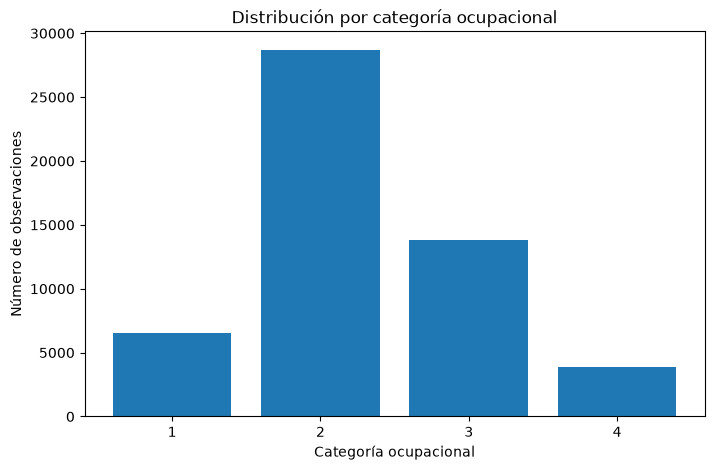

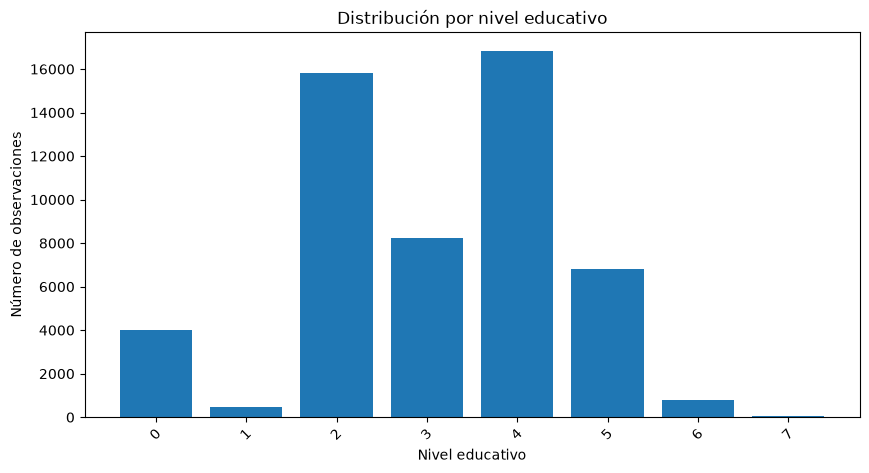

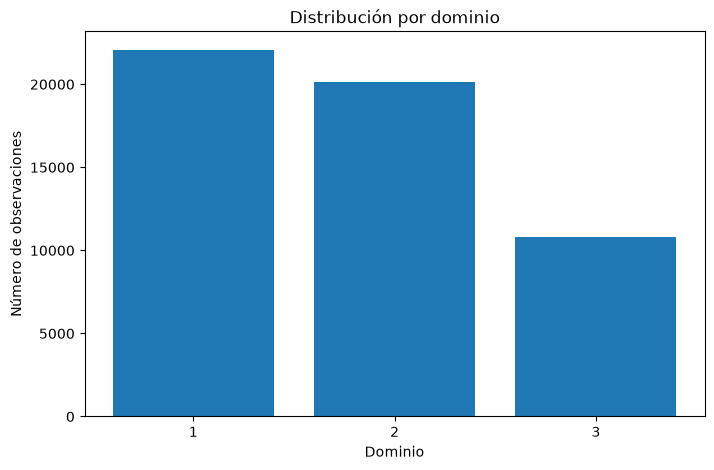

In [68]:
pdf_ocupacion = dist_ocupacion.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    pdf_ocupacion["categoria_ocupacional"],
    pdf_ocupacion["count"]
)

plt.title("Distribución por categoría ocupacional")
plt.xlabel("Categoría ocupacional")
plt.ylabel("Número de observaciones")
plt.show()

pdf_educacion = dist_educacion.toPandas()

plt.figure(figsize=(10, 5))

plt.bar(
    pdf_educacion["nivel_educativo"],
    pdf_educacion["count"]
)

plt.title("Distribución por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Número de observaciones")
plt.xticks(rotation=45)
plt.show()

pdf_dominio = dist_dominio.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    pdf_dominio["dominio"],
    pdf_dominio["count"]
)

plt.title("Distribución por dominio")
plt.xlabel("Dominio")
plt.ylabel("Número de observaciones")
plt.show()

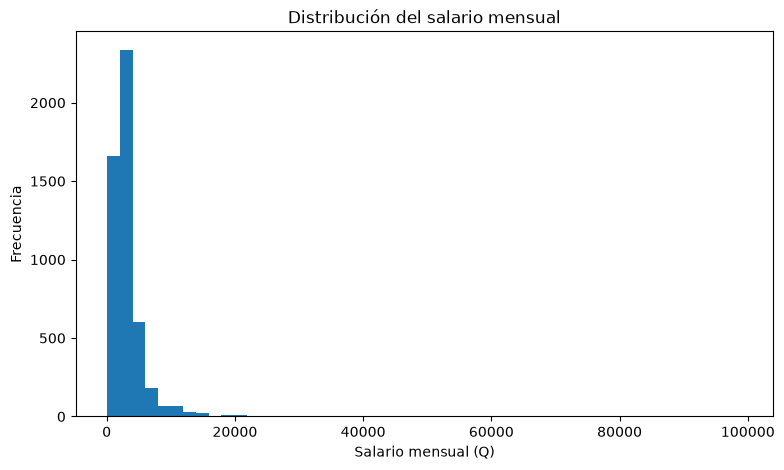

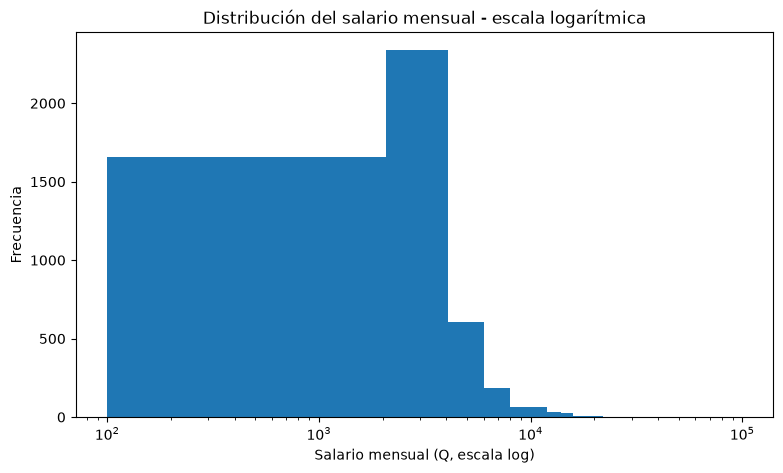

In [69]:
pdf_salario = (
    df_limpio
    .select("salario_mensual")
    .sample(False, 0.15, seed=42)
    .limit(5000)
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.hist(
    pdf_salario["salario_mensual"],
    bins=50
)

plt.title("Distribución del salario mensual")
plt.xlabel("Salario mensual (Q)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(9, 5))

plt.hist(
    pdf_salario["salario_mensual"],
    bins=50
)

plt.xscale("log")

plt.title("Distribución del salario mensual - escala logarítmica")
plt.xlabel("Salario mensual (Q, escala log)")
plt.ylabel("Frecuencia")
plt.show()

+---------------+-----+---------------+
|nivel_educativo|    n|salario_mediano|
+---------------+-----+---------------+
|              0| 3995|         1500.0|
|              1|  459|         2160.0|
|              2|15822|         2200.0|
|              3| 8249|         2800.0|
|              4|16851|         3600.0|
|              5| 6818|         5000.0|
|              6|  771|        10000.0|
|              7|   60|        12000.0|
+---------------+-----+---------------+



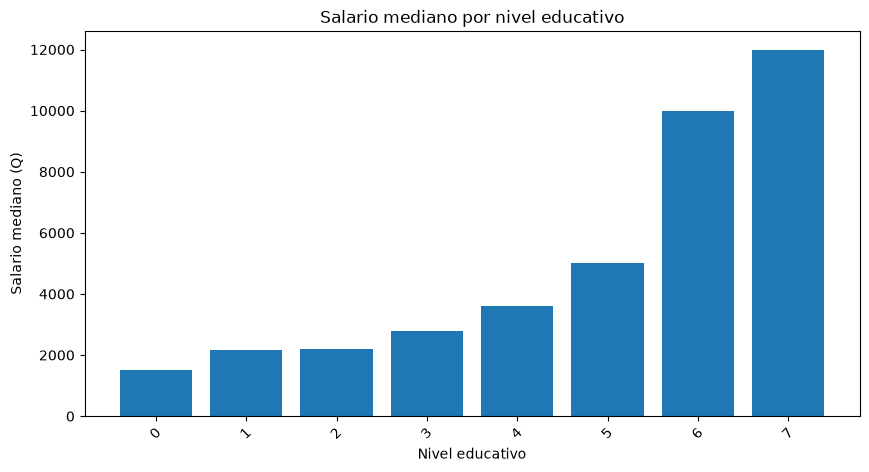

In [70]:
salario_educacion = (
    df_limpio
    .groupBy("nivel_educativo")
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx(
            "salario_mensual",
            0.5
        ).alias("salario_mediano")
    )
    .orderBy("nivel_educativo")
)

salario_educacion.show()

pdf_salario_educacion = salario_educacion.toPandas()

plt.figure(figsize=(10, 5))

plt.bar(
    pdf_salario_educacion["nivel_educativo"],
    pdf_salario_educacion["salario_mediano"]
)

plt.title("Salario mediano por nivel educativo")
plt.xlabel("Nivel educativo")
plt.ylabel("Salario mediano (Q)")
plt.xticks(rotation=45)
plt.show()

+---------------------+-----+---------------+
|categoria_ocupacional|    n|salario_mediano|
+---------------------+-----+---------------+
|                    1| 6575|         5000.0|
|                    2|28702|         3560.0|
|                    3|13842|         1800.0|
|                    4| 3906|         1000.0|
+---------------------+-----+---------------+



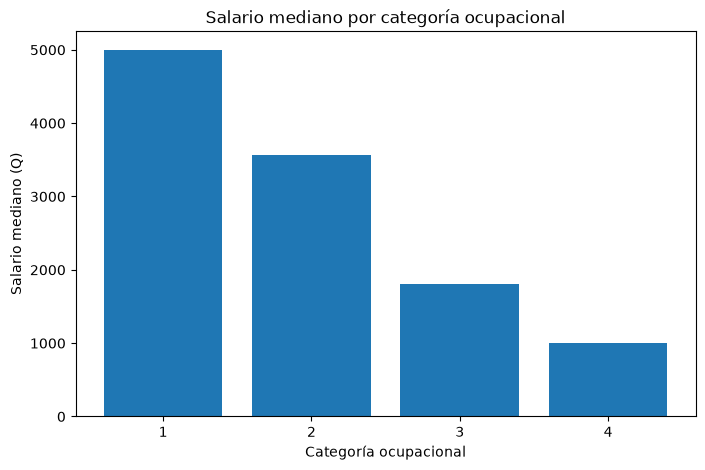

In [71]:
salario_ocupacion = (
    df_limpio
    .groupBy("categoria_ocupacional")
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx(
            "salario_mensual",
            0.5
        ).alias("salario_mediano")
    )
    .orderBy("categoria_ocupacional")
)

salario_ocupacion.show()

pdf_salario_ocupacion = salario_ocupacion.toPandas()

plt.figure(figsize=(8, 5))

plt.bar(
    pdf_salario_ocupacion["categoria_ocupacional"],
    pdf_salario_ocupacion["salario_mediano"]
)

plt.title("Salario mediano por categoría ocupacional")
plt.xlabel("Categoría ocupacional")
plt.ylabel("Salario mediano (Q)")
plt.show()

In [72]:
resumen_trimestre = (
    df_limpio
    .groupBy(
        "periodo_archivo",
        "trimestre_calendario"
    )
    .agg(
        F.count("*").alias("n"),
        F.percentile_approx(
            "salario_mensual",
            0.5
        ).alias("salario_mediano")
    )
    .orderBy("trimestre_calendario")
)

resumen_trimestre.show()

+---------------+--------------------+-----+---------------+
|periodo_archivo|trimestre_calendario|    n|salario_mediano|
+---------------+--------------------+-----+---------------+
|         2025T1|                   1|13419|         3000.0|
|         2025T2|                   2|13492|         3000.0|
|         2025T3|                   3|13450|         3200.0|
|         2025T4|                   4|12664|         3200.0|
+---------------+--------------------+-----+---------------+



In [74]:
variables_corr = [
    "salario_mensual",
    "edad",
    "antiguedad",
    "horas_semanales"
]

assembler_corr = VectorAssembler(
    inputCols=variables_corr,
    outputCol="features_corr"
)

df_corr = assembler_corr.transform(df_limpio)

matriz_corr = (
    Correlation
    .corr(
        df_corr,
        "features_corr",
        "pearson"
    )
    .head()[0]
    .toArray()
)

print(matriz_corr)

26/09/24 22:55:33 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/24 22:55:33 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
[Stage 262:====================================>                 (43 + 19) / 64]

[[ 1.          0.14724926  0.17957441  0.07566511]
 [ 0.14724926  1.          0.48671276 -0.10537763]
 [ 0.17957441  0.48671276  1.         -0.06225561]
 [ 0.07566511 -0.10537763 -0.06225561  1.        ]]


## Interpretación del análisis exploratorio

La población analítica de 2025 está formada por 53,025 observaciones.

### Distribución de las variables categóricas

La categoría ocupacional 2 es la más frecuente, con 28,702
observaciones, seguida por la categoría 3 con 13,842. Las categorías
1 y 4 presentan 6,575 y 3,906 observaciones, respectivamente. Por lo
tanto, la distribución de los registros entre categorías ocupacionales
no es uniforme.

En nivel educativo, las categorías con mayor cantidad de observaciones
son los niveles 4 (16,851) y 2 (15,822), mientras que los niveles 6 y 7
son considerablemente menos frecuentes.

Respecto al dominio, se observan 22,072 registros en el dominio 1,
20,146 en el dominio 2 y 10,807 en el dominio 3.

### Distribución del salario

El salario mensual presenta una distribución marcadamente asimétrica
hacia la derecha. La mayor concentración de observaciones se encuentra
en los salarios relativamente bajos y medios, mientras existe una cola
hacia valores elevados.

La media salarial es aproximadamente Q3,421.68, mientras que la mediana
es Q3,000. La media superior a la mediana es consistente con la
asimetría positiva observada gráficamente. Además, el percentil 75 es
Q4,000 y el percentil 95 es Q8,000, mientras que el máximo observado
alcanza Q99,000.

Los valores extremos se conservaron en el análisis, de acuerdo con los
criterios establecidos para el laboratorio. La visualización con escala
logarítmica se utilizó únicamente para observar con mayor claridad la
forma de la distribución y no modifica la variable salarial utilizada
en el análisis.

### Edad, antigüedad y jornada laboral

La edad promedio es 35.19 años y la mediana es 33 años. El 50% central
de las observaciones se encuentra aproximadamente entre 24 y 44 años.

La antigüedad presenta una media de 5.56 años y una mediana de 2 años,
lo cual indica también una distribución asimétrica. El percentil 75
corresponde a 7 años y el percentil 95 a 22 años.

Las horas habituales de trabajo presentan una media de 46.31 horas
semanales y una mediana de 45 horas. El 50% central se encuentra entre
40 y 55 horas semanales.

### Salario mediano según educación y categoría ocupacional

Se observa una asociación descriptiva entre nivel educativo y salario
mediano. Los salarios medianos obtenidos para los niveles educativos
0 a 7 fueron Q1,500, Q2,100, Q2,200, Q2,800, Q3,600, Q5,000,
Q10,000 y Q12,000, respectivamente.

Este patrón corresponde a una asociación observada en los datos y no
implica por sí mismo una relación causal entre educación y salario.

También existen diferencias entre categorías ocupacionales. Los
salarios medianos fueron Q5,000 para la categoría 1, Q3,560 para la
categoría 2, Q1,800 para la categoría 3 y Q1,000 para la categoría 4.

### Evolución trimestral

El tamaño de la muestra analítica se mantuvo relativamente estable
durante los primeros tres trimestres: 13,419 observaciones en T1,
13,492 en T2 y 13,450 en T3. En T4 disminuyó a 12,664 observaciones.

El salario mediano fue Q3,000 durante T1 y T2 y Q3,200 durante T3 y T4.
Por tanto, se observa un aumento de Q200 en la mediana entre la primera
y segunda mitad del año dentro de los registros analizados.